#### Name: 

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [1]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt


## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

In [ ]:
# part 1




In [ ]:
# part 2
#Defining the function and its derivative
def f(x):
    x = np.array(x, dtype=float)
    x[x < 0] = 0
    return np.exp(x-np.sqrt(x))-x
def df(x):
    x = np.array(x, dtype=float)
    x[x < 0] = 0
    return np.exp(x-np.sqrt(x))*(1-1/(2*np.sqrt(x)))-1

#Defining the function that gives us our newton's method
def Delta(x,f,df):
    output = []
    if type(x)==int or type(x)==float:
        x = [x]
    for i in x:
        if abs(f(i)-df(i))<1e-8:
            output.append(1)
        else:
            output.append(f(i)/df(i))
    return output

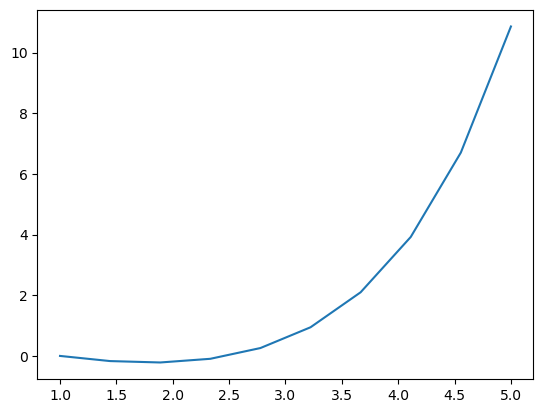

In [ ]:
# part 3
#Initial setup for the problem and to graph
err = 1e-10
x = np.linspace(1,5,10)
x0 = np.copy(x)
delta = np.copy(x)

#Plot of the function, notice 0's near 1 and 2.5
plt.plot(x0,f(x0))
plt.show()

f(x) = 0 at x = ( 1.0 , 2.4909093169 )


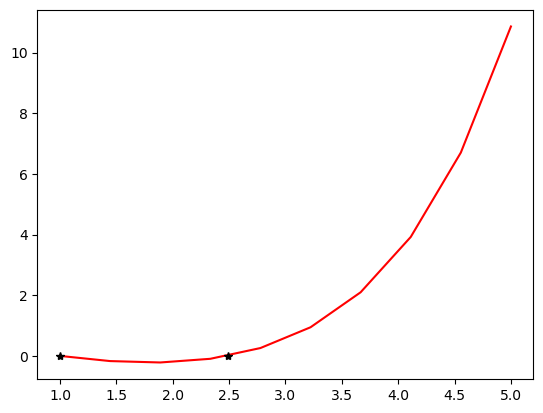

In [87]:
# part 4
#While loop that uses newton's method
while np.max(np.abs(delta))>err:
    delta = Delta(x,f,df)
    x -= delta

#Reducing our array to non-repeats
x = np.sort(list(set(np.round(x,10))))

#Printing our values
print("f(x) = 0 at x = (",x[0],",",x[1],")")
plt.plot(x0,f(x0),"-r")
plt.plot(x,f(x),"*k")
plt.show()

Essentially what I did was define three functions, particularly spending time on the 'Delta' function to make sure that it behaves nicely and as expected for extreme values. I then, because of how I defined the 'Delta' function plug in a range of values, before using newton's method on that set of values, before reducing the set to non-repeated elements and then printing the results. I additionally graph things.

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

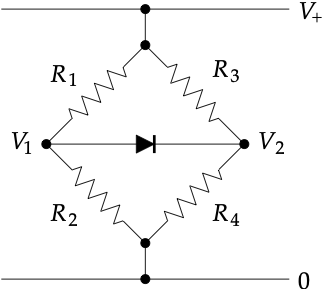

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

$$\frac{V_2-V_+}{R_3} + \frac{V_2}{R_4} - I_0\left(e^{(V_1-V_2)/V_T}-1\right)=0$$

In [ ]:
# part 1

In [ ]:
# part 2

In [90]:
# part 3

#Known variables
Vp,Vt = 5, 0.05 #Volts
r1,r2,r3,r4 = 1000, 4000, 3000, 2000 #Ohms
i0 = 3e-9 #Amps

#Definition of the functions
def f(V1,V2):
    return (V1-Vp)/r1 + V1/r2 + i0*(np.exp((V1-V2)/Vt)-1)
def V1_f(V1,V2):
    return 1/r1 + 1/r2 + i0/Vt * np.exp((V1-V2)/Vt)
def V2_f(V1,V2):
    return -i0/Vt * np.exp((V1-V2)/Vt)
def g(V1,V2):
    return (V2-Vp)/r3 + V2/r4 - i0*(np.exp((V1-V2)/Vt)-1)
def V1_g(V1,V2):
    return -i0/Vt * np.exp((V1-V2)/Vt)
def V2_g(V1,V2):
    return 1/r3 + 1/r4 + i0/Vt * np.exp((V1-V2)/Vt)



In [98]:
# part 4

#Defining our initial properties for the while loop
V10,V20 = 1,1
V1,V2 = V10,V20
err = 1e-11
delta = 1

#While loop using jacobian method for newton's method in a 2-dimensional system
while np.max(delta)>err:
    A11 = V1_f(V1,V2)
    A12 = V2_f(V1,V2)
    A21 = V1_g(V1,V2)
    A22 = V2_g(V1,V2)
    
    #Jacobian Matrix
    A = np.array([[A11,A12],
                  [A21,A22]])
    v = np.array( [f(V1,V2) ,g(V1,V2)], float)
    #Linear algebra to solve
    values = np.linalg.solve(A,v)
    
    #Updating values by the change
    V1 -= values[0]
    V2 -= values[1]
    
    #Geometric change
    delta = np.sqrt(values[0]**2 + values[1]**2)
    
#Rounding our outputs
V1, V2 = round(V1,10), round(V2,10)
diff = round(abs(V1-V2),2)
#Printing results
print("Voltage 1 is:", V1)
print("Voltage 2 is:", V2)
print("The difference is: ~", diff,sep="")

if abs(diff-0.6)<1e-1:
    print("The difference matches expected value!")

Voltage 1 is: 3.4469546189
Voltage 2 is: 2.8295680717
The difference is: ~0.62
The difference matches expected value!


Essentially, I start by defining our functions that will later be used in our Jacobian/Newton method, specifically our functional derivatives that correspond with the elements of our Jacobian matrix and our functions used to evaluate our vector. I additionally define known parameters, before using the said method, and using numpy's 'linalg.solve' function. I then print the findings.